In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

In [6]:
# loading dataset
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [22]:
# encode sex column
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])

In [24]:
# data preprocessing
df = df[['Survived','Pclass','Sex','Age','Fare']]
df.dropna(inplace=True)
X = df.drop('Survived', axis=1)
Y = df['Survived']
X.head()
#Y.head()

,Pclass,Sex,Age,Fare
0,3,1,22.0,7.2500
1,1,0,38.0,71.2833
2,3,0,26.0,7.9250
3,1,0,35.0,53.1000
4,3,1,35.0,8.0500


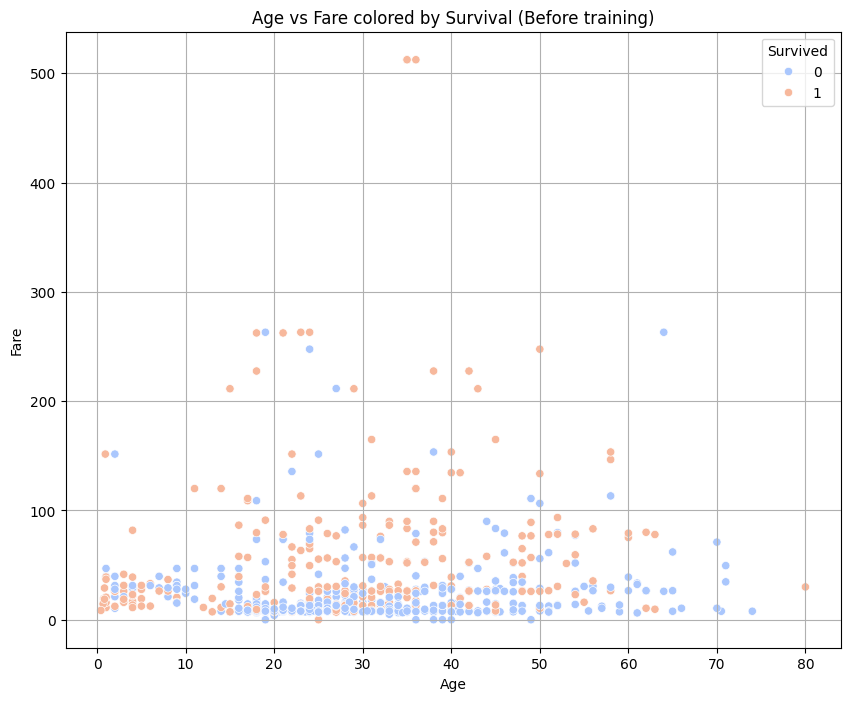

In [25]:
plt.figure(figsize=(10,8))
sns.scatterplot(x='Age',y='Fare',hue='Survived', data=df, palette='coolwarm')
plt.title('Age vs Fare colored by Survival (Before training)')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.grid(True)
plt.show()

In [26]:
# train test split data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y , test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((571, 4), (143, 4))

In [30]:
#training model and checking accuracy
model = LogisticRegression()
model.fit(X_train, Y_train)
Y_pred = model.predict(X_test)
print('Accuracy:',accuracy_score(Y_test, Y_pred))

Accuracy: 0.7552447552447552


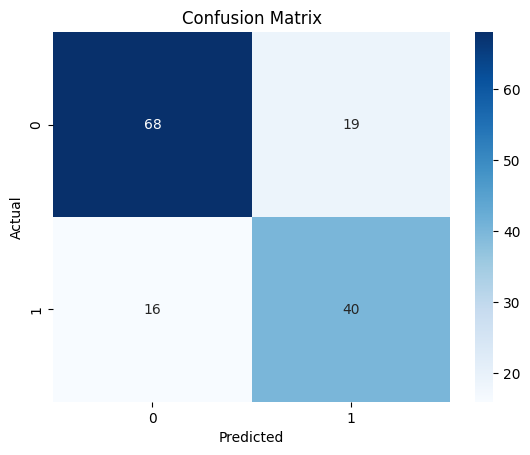

Classification Report:               precision    recall  f1-score   support

           0       0.81      0.78      0.80        87
           1       0.68      0.71      0.70        56

    accuracy                           0.76       143
   macro avg       0.74      0.75      0.75       143
weighted avg       0.76      0.76      0.76       143



In [31]:
# evaluation
cm = confusion_matrix(Y_test, Y_pred)
sns.heatmap(cm, annot=True ,fmt='d',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print('Classification Report:',classification_report(Y_test,Y_pred))